<a href="https://colab.research.google.com/github/Adyan213/Hands-On-ML/blob/main/chapter_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

np.random.seed(42)
m=100
X=2*np.random.rand(m, 1)
y=4+3*X+np.random.randn(m, 1)

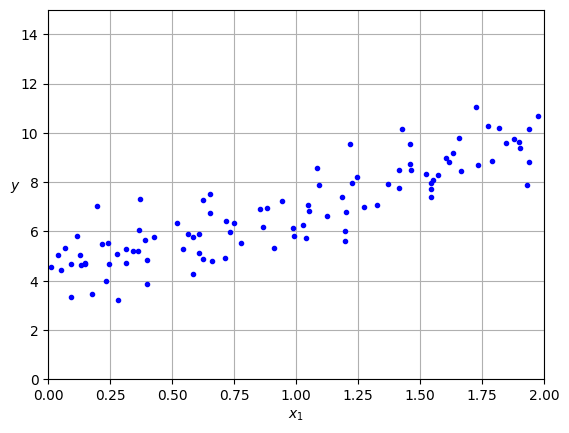

In [ ]:
import matplotlib.pyplot as plt
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

In [ ]:
from sklearn.preprocessing import add_dummy_feature
X_b=add_dummy_feature(X)
theta_best=np.linalg.inv(X_b.T@X_b)@X_b.T@y

theta_best

array([[4.21509616],
       [2.77011339]])

In [ ]:
X_new=np.array([[0], [2]])
X_new_b=add_dummy_feature(X_new)
y_predict=X_new_b@theta_best

In [ ]:
y_predict

array([[4.21509616],
       [9.75532293]])

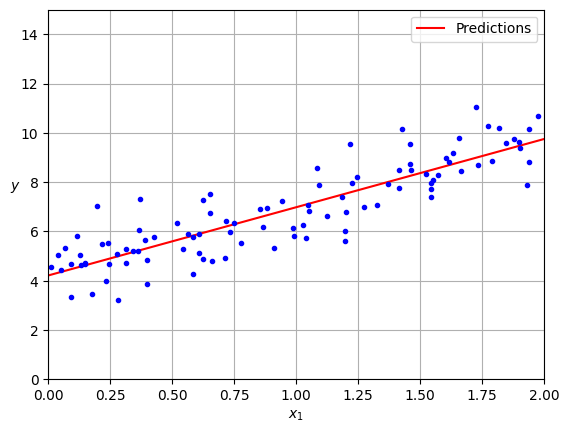

In [ ]:
import matplotlib.pyplot as plt
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend()
plt.grid()

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [ ]:
theta_best_svd, residuals, rank, s=np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [ ]:
np.linalg.pinv(X_b)@y  # psuedo inverse

array([[4.21509616],
       [2.77011339]])

In [ ]:
eta=0.1
n_epochs=1000
m=len(X_b)

np.random.seed(42)
theta=np.random.randn(2,1)

for epoch in range(n_epochs):
  gradients=2/m*X_b.T@(X_b@theta-y)
  theta=theta-eta*gradients

theta

array([[4.21509616],
       [2.77011339]])

In [ ]:
n_epochs=50
t0, t1=5, 50

def learning_schedule(t):
  return t0/(t+t1)

theta=np.random.randn(2,1)

for epoch in range(n_epochs):
  for i in range(m):
    random_index=np.random.randint(m)
    xi=X_b[random_index:random_index+1]
    yi=y[random_index:random_index+1]
    gradients=2*xi.T*(xi@theta-yi)
    eta=learning_schedule(epoch*m+i)
    theta=theta-eta*gradients

In [ ]:
theta

array([[4.20742938],
       [2.74264448]])

In [ ]:
from sklearn.linear_model import SGDRegressor
sgd_reg=SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.1, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) #ravel because fit expects 1D targets

SGDRegressor(eta0=0.1, n_iter_no_change=100, penalty=None, random_state=42,
             tol=1e-05)

In [ ]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.22612746]), array([2.79035392]))

In [ ]:
np.random.seed(42)
m=100
X=6*np.random.rand(m,1)-3
y=0.5*X**2+X+2+np.random.randn(m, 1)

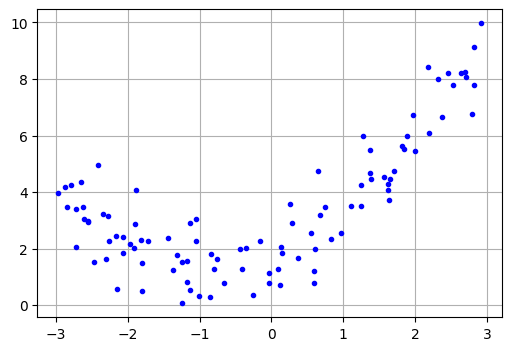

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(X, y, "b.")
plt.grid()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
poly_features=PolynomialFeatures(degree=2, include_bias=False)
X_poly=poly_features.fit_transform(X)
print(X[0])
print(X_poly[0])

[-0.75275929]
[-0.75275929  0.56664654]


In [ ]:
lin_reg=LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

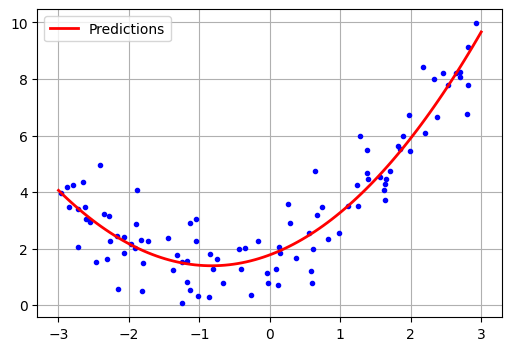

In [ ]:
X_new=np.linspace(-3,3,100).reshape(100,1)
X_new_poly=poly_features.transform(X_new)
y_new=lin_reg.predict(X_new_poly)

plt.figure(figsize=(6,4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.grid()
plt.legend()

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores=learning_curve(LinearRegression(), X, y,
                                                       train_sizes=np.linspace(0.01, 1, 40),
                                                       cv=5, scoring="neg_mean_squared_error")
train_errors=-train_scores.mean(axis=1)
valid_errors=-valid_scores.mean(axis=1)

train_sizes, train_errors, valid_errors

(array([ 1,  2,  4,  6,  8, 10, 12, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33,
        35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67,
        69, 71, 73, 75, 77, 80]),
 array([-0.00000000e+00,  1.18329136e-31,  1.56063986e+00,  2.46313116e+00,
         2.90127253e+00,  2.81646236e+00,  3.61330802e+00,  3.15270237e+00,
         3.02003505e+00,  3.17576944e+00,  3.13954228e+00,  3.14994690e+00,
         3.27292776e+00,  3.07800510e+00,  3.08551701e+00,  3.12869523e+00,
         3.07403095e+00,  3.17946978e+00,  3.07287161e+00,  3.11237024e+00,
         3.05837025e+00,  3.10560750e+00,  3.13382115e+00,  3.03899926e+00,
         3.02447732e+00,  3.16796822e+00,  3.23229318e+00,  3.19079454e+00,
         3.11923203e+00,  3.05466528e+00,  3.08183838e+00,  3.07726659e+00,
         3.11511815e+00,  3.03295384e+00,  3.06153261e+00,  3.06609301e+00,
         3.03195600e+00,  3.01719274e+00,  3.02539517e+00,  3.02119451e+00]),
 array([7.95973929, 6.22837142, 9.85904265, 3.391393

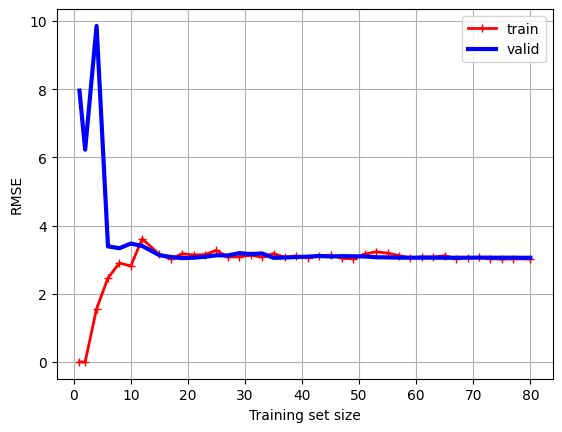

In [ ]:
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.grid()
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.legend()

In [ ]:
from sklearn.pipeline import make_pipeline

polynomial_regression=make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression()
)
train_sizes, train_scores, valid_scores=learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1, 40),
    cv=5, scoring="neg_mean_squared_error"
)

(np.float64(0.0), np.float64(80.0), np.float64(0.0), np.float64(2.5))

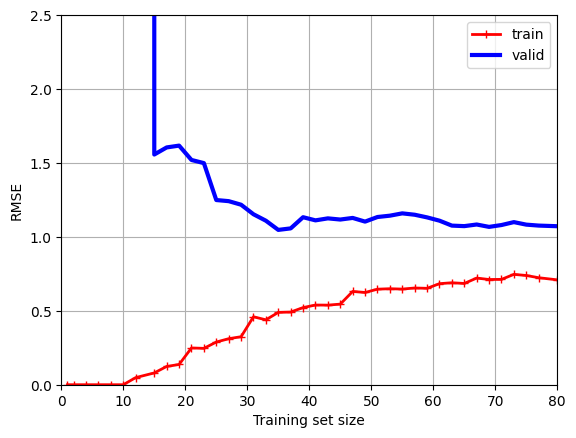

In [ ]:
train_errors=-train_scores.mean(axis=1)
valid_errors=-valid_scores.mean(axis=1)

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.grid()
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.legend()
plt.axis([0, 80, 0, 2.5])

In [ ]:
np.random.seed(42)
m=20
X=3*np.random.rand(m,1)
y=1+0.5*X+np.random.randn(m,1)/1.5
X_new=np.linspace(0, 3, 100).reshape(100,1)

(np.float64(0.0), np.float64(3.0), np.float64(0.0), np.float64(3.5))

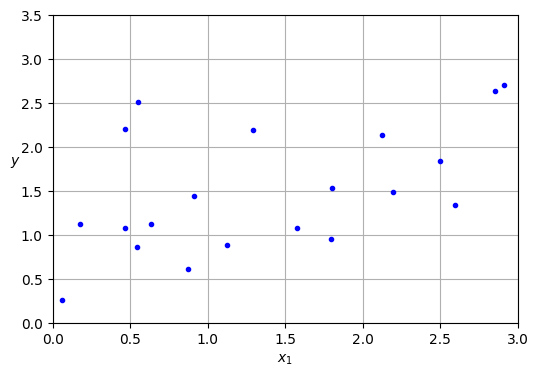

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(X, y, "b.")
plt.grid()
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])

In [ ]:
from sklearn.linear_model import Ridge

ridge_reg=Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55325833])

In [ ]:
sgd_reg=SGDRegressor(penalty="l2",alpha=0.1/m, max_iter=1000, tol=None,
                     eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.55302613])

In [ ]:
from sklearn.linear_model import Lasso
lasso_reg=Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

In [ ]:
from sklearn.linear_model import ElasticNet
elastic_net=ElasticNet(alpha=1, l1_ratio=0.5)

elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.50467735])

In [ ]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
m=100
X=6*np.random.rand(m, 1)-3
y=0.5*X**2+X+2+np.random.randn(m, 1)

X_train, y_train, X_valid, y_valid=X[:m//2], y[:m//2, 0], X[m//2:], y[m//2:, 0]

preprcessing=make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    StandardScaler()
)
X_train_prep=preprcessing.fit_transform(X_train)
X_valid_prep=preprcessing.transform(X_valid)
sgd_reg=SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs=500
best_valid_rmse=float('inf')

for epoch in range(n_epochs):
  sgd_reg.partial_fit(X_train_prep, y_train)
  y_valid_predict=sgd_reg.predict(X_valid_prep)
  val_error=root_mean_squared_error(y_valid, y_valid_predict)
  if val_error<best_valid_rmse:
    best_epoch=deepcopy(epoch)
    best_valid_rmse=val_error
    best_model=deepcopy(sgd_reg)

In [ ]:
from sklearn.datasets import load_iris

In [ ]:
iris=load_iris(as_frame=True)

In [ ]:
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [ ]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
iris.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
X=iris.data[["petal width (cm)"]].values
y=iris.target_names[iris.target]=='virginica'
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=42)

log_reg=LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

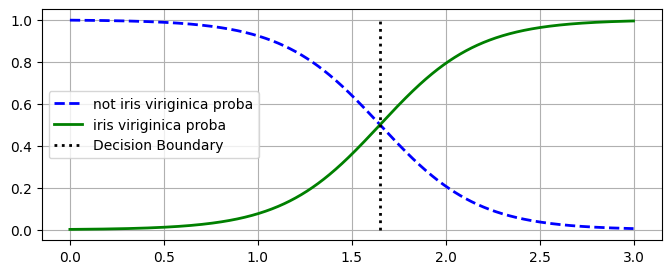

In [ ]:
X_new=np.linspace(0,3,1000).reshape(-1,1)
y_proba=log_reg.predict_proba(X_new)
decision_boundary=X_new[y_proba[:, 1]>=0.5][0,0]

plt.figure(figsize=(8, 3))
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="not iris viriginica proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="iris viriginica proba")
plt.plot([decision_boundary, decision_boundary], [0,1], "k:", linewidth=2,
         label="Decision Boundary")
plt.legend(loc="center left")
plt.grid()

In [ ]:
decision_boundary

np.float64(1.6516516516516517)

In [ ]:
log_reg.predict([[1.7], [1.5]])

array([ True, False])

In [ ]:
X=iris.data[["petal length (cm)", "petal width (cm)"]].values
y=iris["target"]
X_train, X_test, y_train, y_test=train_test_split(X, y, random_state=42)

softmax_reg=LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [ ]:
softmax_reg.predict([[5, 2]])

array([2])

In [ ]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])

In [ ]:
X=iris.data[["petal length (cm)", "petal width (cm)"]].values
y=iris["target"].values

In [ ]:
X_with_bias=np.c_[np.ones(len(X)), X]

In [ ]:
test_ratio=0.2
validation_ratio=0.2
total_size=len(X_with_bias)

test_size=int(total_size*test_ratio)
validation_size=int(total_size*validation_ratio)
train_size=total_size-test_size-validation_size

np.random.seed(42)
rnd_indices=np.random.permutation(total_size)

X_train=X_with_bias[rnd_indices[:train_size]]
X_valid=X_with_bias[rnd_indices[train_size:-test_size]]
X_test=X_with_bias[rnd_indices[-test_size:]]
y_train=y[rnd_indices[:train_size]]
y_valid=y[rnd_indices[train_size:-test_size]]
y_test=y[rnd_indices[-test_size:]]

In [ ]:
def to_one_hot(y):
  return np.diag(np.ones(y.max()+1))[y]

In [ ]:
y_train[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [ ]:
to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [ ]:
Y_train_one_hot=to_one_hot(y_train)
Y_valid_one_hot=to_one_hot(y_valid)
Y_test_one_hot=to_one_hot(y_test)

In [ ]:
mean=X_train[:, 1:].mean(axis=0)
std=X_train[:, 1:].std(axis=0)

X_train[:, 1:]=(X_train[:, 1:]-mean)/std
X_valid[:, 1:]=(X_valid[:, 1:]-mean)/std
X_test[:, 1:]=(X_test[:, 1:]-mean)/std

In [ ]:
def softmax(logits):
  exps=np.exp(logits)
  exp_sums=exps.sum(axis=1, keepdims=True)
  return exps/exp_sums

In [ ]:
n_inputs=X_train.shape[1]
n_outputs=len(np.unique(y_train))

In [ ]:
eta=0.5
n_epochs=5001
m=len(X_train)
epsilon=1e-5

np.random.seed(42)
theta=np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
  logits=X_train@theta
  Y_proba=softmax(logits)
  if epoch%1000==0:
    Y_proba_valid=softmax(X_valid@theta)
    xentropy_losses=-(Y_valid_one_hot*np.log(Y_proba_valid+epsilon))
    print(epoch, xentropy_losses.sum(axis=1).mean())
  error =Y_proba-Y_train_one_hot
  gradients=1/m*X_train.T@error
  theta=theta-eta*gradients

0 3.7085808486476917
1000 0.14519367480830644
2000 0.1301309575504088
3000 0.12009639326384539
4000 0.11372961364786884
5000 0.11002459532472425


In [ ]:
theta

array([[ 0.41931626,  6.11112089, -5.52429876],
       [-6.53054533, -0.74608616,  8.33137102],
       [-5.28115784,  0.25152675,  6.90680425]])

In [ ]:
logits=X_valid@theta
Y_proba=softmax(logits)
y_predict=Y_proba.argmax(axis=1)

accuracy_score=(y_predict==y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

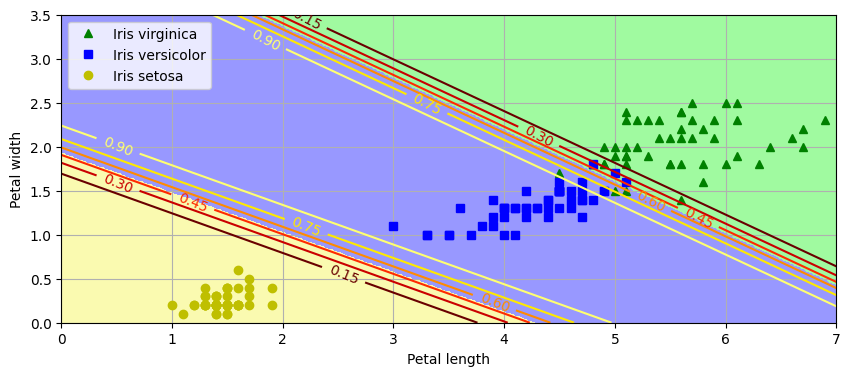

In [ ]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]
X_new = (X_new - mean) / std
X_new_with_bias = np.c_[np.ones(len(X_new)), X_new]

logits = X_new_with_bias @ theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

zz1 = Y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 7, 0, 3.5])
plt.grid()
plt.show()

In [ ]:
logits=X_test@theta
Y_proba=softmax(logits)
y_predict=Y_proba.argmax(axis=1)

accuracy_score=(y_predict==y_test).mean()
accuracy_score

np.float64(0.9666666666666667)